# Titanic Dataset — EDA

## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/dataset.csv")

In [3]:
df.head() # проверка на успешную загрузку данных

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Первичный обзор данных

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe() #для числовых столбцов

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum() # кол-во пропушенных ячеек по столбцам

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. Очистка данных

### 3.1 Пропуски

In [9]:
df = df.drop(columns=["Cabin"]) # удаление столбца Cabin

In [10]:
age_median = df["Age"].median() # вычисление медианы

In [11]:
df["Age"] = df["Age"].fillna(age_median) # заполнение пропусков в столбцах Age медианой

In [12]:
embarked_mode = df["Embarked"].mode()[0]
embarked_mode

'S'

In [13]:
df["Embarked"] = df["Embarked"].fillna(embarked_mode) # заполнение пропусков в столбцах Embarked самым частым значением

In [14]:
df.isnull().sum() # проверка результата 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### 3.2 Дубликаты

In [15]:
df.duplicated().sum() # проверка на дубли

0

In [16]:
# Если бы были дубли: df = df.drop_duplicates()

### 3.3 Типы данных

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [18]:
# PassengerId int64 - идентификатор
# Survived int64 - бинарное число (признак (выжил 1\не выжил 0))
# Pclass int64 - числовая категория (класс билета)
# Name object - текст (Имя пассажира)
# Sex object - категория (пол)
# Age float64 - число (возраст)
# SibSp int64 - число (кол-во сестер\братьев\супругов на борту)
# Parch int64 - число (кол-во родителей и детей на борту)
# Ticket object - текст (название билета)
# Fare float64 - число (стоимость билета)
# Embarked object - категория (Порт посадки)

## 4. Нормализация числовых признаков

In [19]:
numeric_columns = ["Age", "SibSp", "Parch", "Fare"]

$$
x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

In [20]:
df_normalized = df.copy()

df_normalized[numeric_columns] = (df_normalized[numeric_columns] - df_normalized[numeric_columns].min()) / (df_normalized[numeric_columns].max() - df_normalized[numeric_columns].min())

In [21]:
df_normalized[numeric_columns].describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,0.363679,0.065376,0.063599,0.062858
std,0.163605,0.137843,0.134343,0.096995
min,0.000000,0.000000,0.000000,0.000000
25%,0.271174,0.000000,0.000000,0.015440
50%,0.346569,0.000000,0.000000,0.028213
75%,0.434531,0.125000,0.000000,0.060508
max,1.000000,1.000000,1.000000,1.000000


## 5. Визуализация данных

### 5.1 Гистограммы

#### Гистограмма возраста

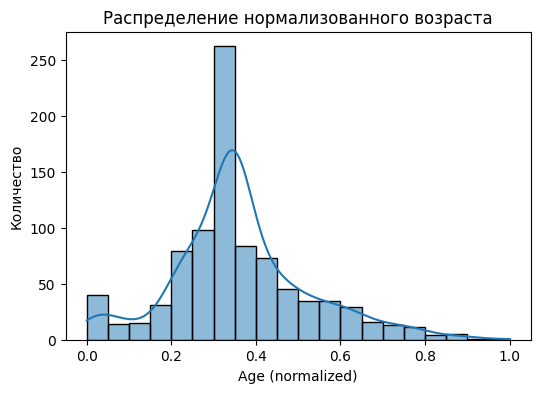

In [22]:
plt.figure(figsize=(6, 4)) # размер графика
sns.histplot(df_normalized["Age"], bins=20, kde=True) # гистограмма + KDE-кривая
plt.title("Распределение нормализованного возраста")
plt.xlabel("Age (normalized)")
plt.ylabel("Количество")
plt.show()

#### Гистограмма стоимости билета

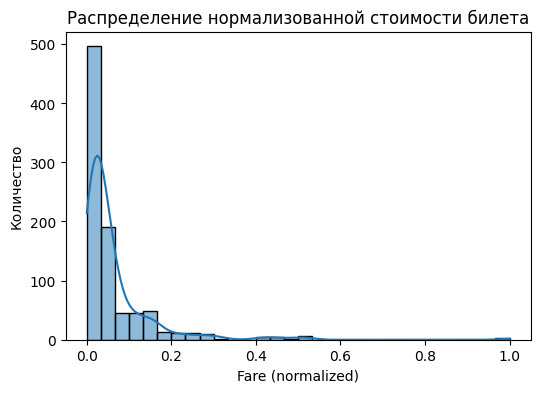

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(df_normalized["Fare"], bins=30, kde=True)
plt.title("Распределение нормализованной стоимости билета")
plt.xlabel("Fare (normalized)")
plt.ylabel("Количество")
plt.show()

#### Гистограмма кол-ва сестер\братьев\супругов на борту

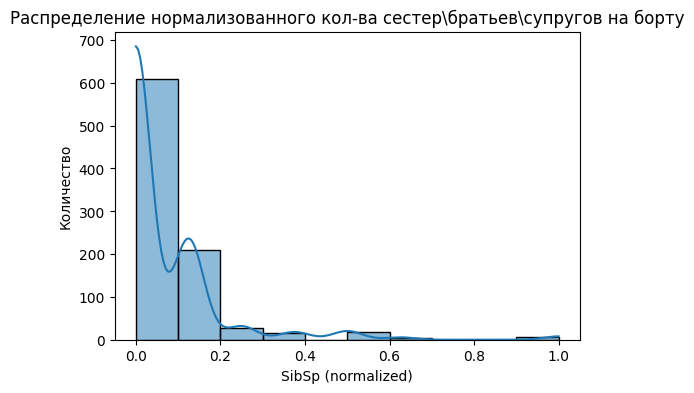

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(df_normalized["SibSp"], bins=10, kde=True)
plt.title("Распределение нормализованного кол-ва сестер\братьев\супругов на борту")
plt.xlabel("SibSp (normalized)")
plt.ylabel("Количество")
plt.show()

#### Гистограмма кол-ва родителей и детей на борту

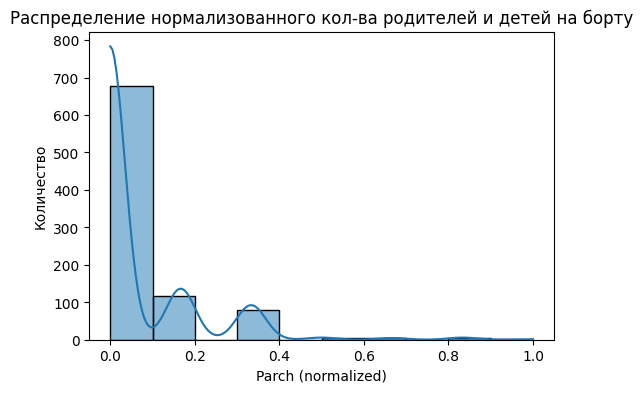

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(df_normalized["Parch"], bins=10, kde=True)
plt.title("Распределение нормализованного кол-ва родителей и детей на борту")
plt.xlabel("Parch (normalized)")
plt.ylabel("Количество")
plt.show()

### 5.2 Корреляция

In [26]:
corr_df_normal = df_normalized[["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"]].corr()
corr_df_normal

,Survived,Pclass,Age,Fare,SibSp,Parch
Survived,1.000000,-0.338481,-0.064910,0.257307,-0.035322,0.081629
Pclass,-0.338481,1.000000,-0.339898,-0.549500,0.083081,0.018443
Age,-0.064910,-0.339898,1.000000,0.096688,-0.233296,-0.172482
Fare,0.257307,-0.549500,0.096688,1.000000,0.159651,0.216225
SibSp,-0.035322,0.083081,-0.233296,0.159651,1.000000,0.414838
Parch,0.081629,0.018443,-0.172482,0.216225,0.414838,1.000000


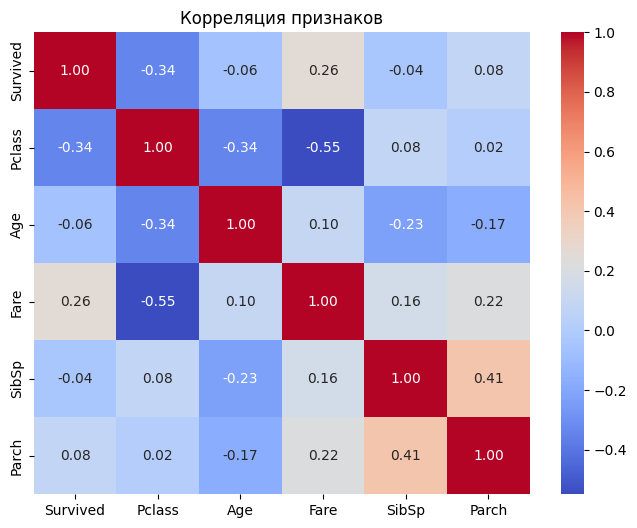

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df_normal, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция признаков")
plt.show()

## 6. Итоговый отчёт о качестве данных

В рамках работы был проведён разведочный анализ данных (EDA) для датасета Titanic.

### Исходные данные

- Размер датасета: 891 строка и 12 столбцов.
- Каждая строка соответствует одному пассажиру.
- Данные содержат как числовые, так и категориальные признаки.

### Выявленные проблемы качества данных

- В столбце "Age" обнаружены пропущенные значения (177 записей).
- В столбце "Cabin" обнаружено большое количество пропусков значений (687 записей).
- В столбце "Embarked" обнаружено незначительное количество пропусков (2 записи).
- Дубликаты строк в датасете отсутствуют.

### Очистка данных

- Столбец "Cabin" был удалён из-за большого кол-ва пропущенных значений и низкой информативности для анализа
- Пропущенные значения в столбце "Age" были заполнены медианным значением
- Пропущенные значения в столбце "Embarked" были заполнены наиболее часто встречающимся значениям
- Проверка дубликатов показала отсутствие повторяющихся строк

### Нормализация данных

- Нормализвация применялась исключительно к количественным признакам (числовым столбцам)
- Числовые столбцы "Age", "SibSp", "Parch", "Fare" были нормализованы методом Min-Max
- Нормализация выполнялась на копии оригинального датасета

### Анализ визуализации и корреляции

- Были построены гистограммы для признаков "Age", "SibSp", "Parch", "Fare", что позволило изучить форму их распределений
- Построена корреляционная матрица и heatmap для числовых признаков
- Наиболее выраженные зависимости:
  - выживаемость пассажиров и класс билета ("Survived" & "Pclass")
  - стоимость билета и класс билета ("Fare" & "Pclass")
  - размер семеной группы ("SibSp" & "Parch")

### Итог

После выполнения очистки и нормализации датасет не содержит пропущенных значений и дубликатов и готов к дальнейшему анализу

##

# Построение базовой ML-модели

## Подготовка данных для машинного обучения

In [28]:
pip install scikit-learn

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [30]:
Y = df["Survived"] # таргет\целевая переменная

In [31]:
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket"])

In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


### Кодирование One-Hot Encoding

In [33]:
X_encoded = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True) # кодировка категориальных признаков в числовые

In [34]:
bool_cols = X_encoded.select_dtypes(include="bool").columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int) # данные ставновятся явными

In [35]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-null    int32  
 6   Embarked_Q  891 non-null    int32  
 7   Embarked_S  891 non-null    int32  
dtypes: float64(2), int32(3), int64(3)
memory usage: 45.4 KB


In [36]:
X_encoded.describe()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.361582,0.523008,0.381594,32.204208,0.647587,0.086420,0.725028
std,0.836071,13.019697,1.102743,0.806057,49.693429,0.477990,0.281141,0.446751
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,0.000000,1.000000
75%,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,0.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000


### Разделение данных на train / test

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42, stratify=Y)

In [38]:
X_train.shape, X_test.shape

((712, 8), (179, 8))

In [39]:
Y_train.value_counts(normalize=True) # проверка распределения классов

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

In [40]:
Y_test.value_counts(normalize=True) # проверка распределения классов

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

## Нормализация признаков для LogisticRegression

### Метод нормализации StandardScaler

$$
z = \frac{x - \mu}{\sigma},
\quad
\mu \text{ — среднее значение},
\quad
\sigma \text{ — стандартное отклонение}
$$

In [41]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

In [42]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features]) # обучаем scaler

X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features]) # применяем те же параметры мю и сигма

In [43]:
X_train_scaled[numeric_features].describe()

,Age,Fare,SibSp,Parch,Pclass
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,2.120651e-16,-1.746418e-17,-5.613487e-18,-1.621674e-17,-1.821265e-16
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.229476e+00,-6.625632e-01,-4.650843e-01,-4.661832e-01,-1.571457e+00
25%,-5.727156e-01,-4.981542e-01,-4.650843e-01,-4.661832e-01,-3.709448e-01
50%,-1.120778e-01,-3.615930e-01,-4.650843e-01,-4.661832e-01,8.295675e-01
75%,5.021060e-01,-1.707070e-02,4.783345e-01,-4.661832e-01,8.295675e-01
max,3.880117e+00,1.000533e+01,7.082266e+00,6.697610e+00,8.295675e-01


Отрицательные значения в describe() появляются из-за стандартизации признаков. После применения StandardScaler данные приводятся к распределению со средним 0 и стандартным отклонением 1, поэтому значения ниже среднего становятся отрицательными, выше — положительными.

In [44]:
X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,0.513812,1,0,1
481,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,1,0,1
527,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,1,0,1
855,0.829568,-0.879807,-0.465084,0.727782,-0.467874,0,0,1
801,-0.370945,0.118241,0.478335,0.727782,-0.115977,0,0,1


## Обучение LogisticRegression и получение предсказаний

In [45]:
log_reg = LogisticRegression(max_iter=1000, random_state=42) # создание модели
# max_iter - максимальное число итераций обучения модели логистической регрессии.

In [46]:
log_reg.fit(X_train_scaled, Y_train) # обучение модели на train-данных

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
Y_pred = log_reg.predict(X_test_scaled) # Предсказание классов

In [48]:
Y_proba = log_reg.predict_proba(X_test_scaled)[:, 1] # Предсказание вероятностей

In [49]:
Y_pred[:10], Y_proba[:10]

(array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0], dtype=int64),
 array([0.06973844, 0.04934248, 0.15661535, 0.03687622, 0.66899951,
        0.43502699, 0.74467904, 0.33027661, 0.35154229, 0.1640622 ]))

In [50]:
log_reg.classes_

array([0, 1], dtype=int64)

## Метрики качества модели

In [51]:
accuracy = accuracy_score(Y_test, Y_pred) # общая точность
accuracy

0.8044692737430168

In [52]:
precision = precision_score(Y_test, Y_pred) # точность положительных предсказаний
precision

0.7931034482758621

In [53]:
recall = recall_score(Y_test, Y_pred) # полнота положительного класса (сколько модель нашла)
recall

0.6666666666666666

In [54]:
F1 = f1_score(Y_test, Y_pred) # баланс precision и recall (метрика качества классификации)
F1

0.7244094488188977

In [55]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, F1]
})

metrics_df

,Metric,Value
0,Accuracy,0.804469
1,Precision,0.793103
2,Recall,0.666667
3,F1-score,0.724409


## Матрица ошибок LogisticRegression

In [56]:
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[98, 12],
       [23, 46]], dtype=int64)

In [57]:
len(Y_test), len(Y_pred)

(179, 179)

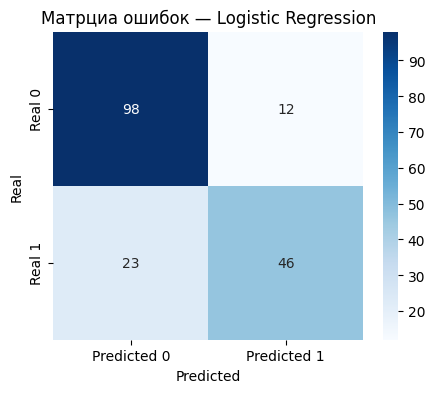

In [58]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Real 0", "Real 1"]
)
plt.title("Матрциа ошибок — Logistic Regression")
plt.ylabel("Real")
plt.xlabel("Predicted")
plt.show()

### Краткий итог по heatmap

Матрица ошибок показывает, что модель LogisticRegression чаще ошибается в виде ложных отрицаний (FN), то есть не предсказывает выживание для части пассажиров, которые фактически выжили (нижний левый угол). Это объясняет умеренное значение recall и общее значение accuracy около 80%.


## ROC-кривая и AUC

In [59]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_proba)
auc_score = roc_auc_score(Y_test, Y_proba)

auc_score # показывает насколько модель различает классы
# AUC = вероятность того, что модель поставит более высокую вероятность положительному объекту, чем отрицательному

0.8438735177865613

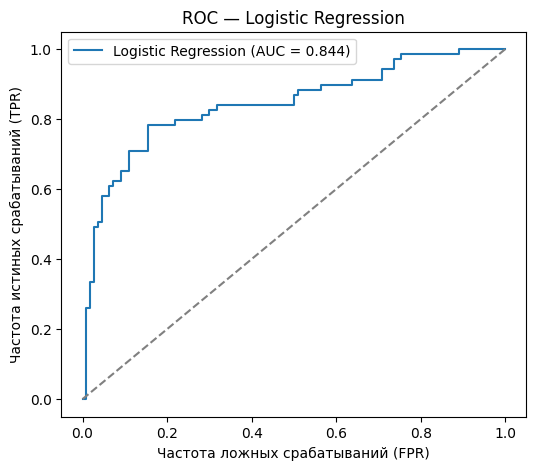

In [60]:
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Частота ложных срабатываний (FPR)")
plt.ylabel("Частота истиных срабатываний (TPR)")
plt.title("ROC — Logistic Regression")
plt.legend()
plt.show()

### Краткий итог по ROC

ROC-кривая показывает способность модели различать классы при различных порогах вероятности (predict). Значение AUC примерно 0.844, что свидетельствует о хорошем качестве ранжирования пассажиров по вероятности выживания.

## Обучение RandomForest, получение предсказаний и сравнение с LogisticRegression

In [61]:
ran_f = RandomForestClassifier(
    n_estimators=500, # количество деревьев
    max_depth=None, # деревья могут расти свободно
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

In [62]:
ran_f.fit(X_train, Y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
Y_pred_rf = ran_f.predict(X_test)
Y_proba_rf = ran_f.predict_proba(X_test)[:, 1]

In [64]:
Y_pred_rf[:10], Y_proba_rf[:10]

(array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0], dtype=int64),
 array([0.12096325, 0.16135766, 0.09      , 0.02666269, 0.822     ,
        0.28496325, 0.86096325, 0.85324547, 0.496     , 0.32696325]))

In [65]:
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
accuracy_rf

0.8212290502793296

In [66]:
precision_rf = precision_score(Y_test, Y_pred_rf)
precision_rf

0.8032786885245902

In [67]:
recall_rf = recall_score(Y_test, Y_pred_rf)
recall_rf

0.7101449275362319

In [68]:
F1_rf = f1_score(Y_test, Y_pred_rf)
F1_rf

0.7538461538461538

In [69]:
metrics_rf = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy_rf, precision_rf, recall_rf, F1_rf]
})

metrics_rf

,Metric,Value
0,Accuracy,0.821229
1,Precision,0.803279
2,Recall,0.710145
3,F1-score,0.753846


## Матрица ошибок RandomForest

In [70]:
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
cm_rf

array([[98, 12],
       [20, 49]], dtype=int64)

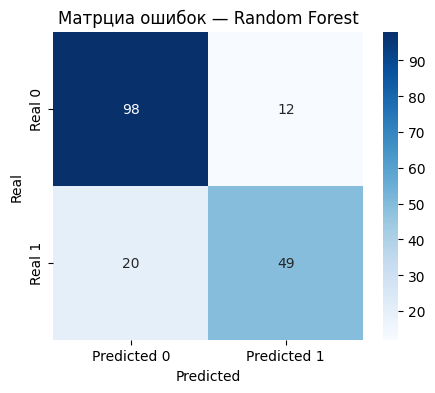

In [71]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Real 0", "Real 1"]
)
plt.title("Матрциа ошибок — Random Forest")
plt.ylabel("Real")
plt.xlabel("Predicted")
plt.show()

### Краткий итог по heatmap

По сравнению с heatmap от Logistic Regression ситуация не сильно поменялась, модель Random Forest чаще ошибается в виде ложных отрицаний (FN)

## ROC-кривая и AUC

In [72]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_proba_rf)
auc_score = roc_auc_score(Y_test, Y_proba_rf)

auc_score # показывает насколько модель различает классы

0.8357048748353096

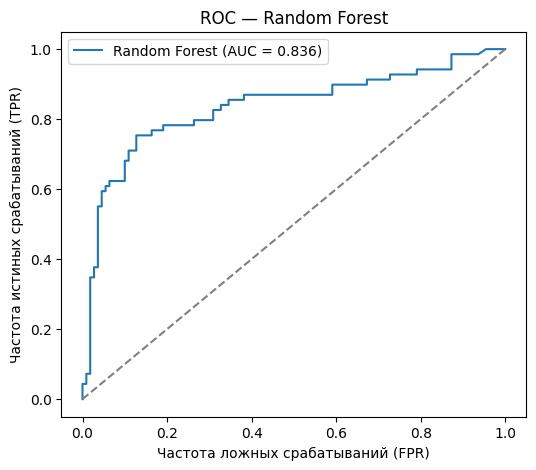

In [73]:
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Частота ложных срабатываний (FPR)")
plt.ylabel("Частота истиных срабатываний (TPR)")
plt.title("ROC — Random Forest")
plt.legend()
plt.show()

### Краткий итог по ROC

Значение AUC примерно 0.836, что свидетельствует о хорошем качестве ранжирования пассажиров по вероятности выживания, но при этом меньше, чем было у модели Logistic Regression

## Пересмотр данных и добавление смысловых конструкций для модели Random Forest

In [74]:
df_fe = df.copy()

In [75]:
df_fe["Title"] = df_fe["Name"].str.extract(r",\s*([^\.]+)\.") # извлекаем Title из Name

In [76]:
df_fe["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [77]:
rare_titles = df_fe["Title"].value_counts()[df_fe["Title"].value_counts() < 10].index # получаем редкие title

df_fe["Title"] = df_fe["Title"].replace(rare_titles, "Rare") # заменяем все редки title на "Rare"

In [78]:
Y_fe = df_fe["Survived"] # таргет\целевая переменная

In [79]:
X_fe = df_fe.drop(columns=["Survived", "PassengerId", "Ticket", "Name"])

In [80]:
X_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
 7   Title     891 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB


### One-hot кодирование категориальных признаков

In [81]:
X_encoded_fe = pd.get_dummies(X_fe, columns=["Sex", "Embarked", "Title"], drop_first=True)

In [82]:
bool_cols_fe = X_encoded_fe.select_dtypes(include="bool").columns
X_encoded_fe[bool_cols_fe] = X_encoded_fe[bool_cols_fe].astype(int) # данные ставновятся явными

In [83]:
X_encoded_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-null    int32  
 6   Embarked_Q  891 non-null    int32  
 7   Embarked_S  891 non-null    int32  
 8   Title_Miss  891 non-null    int32  
 9   Title_Mr    891 non-null    int32  
 10  Title_Mrs   891 non-null    int32  
 11  Title_Rare  891 non-null    int32  
dtypes: float64(2), int32(7), int64(3)
memory usage: 59.3 KB


### Разделение данных на train / test с новыми данными

In [84]:
X_train_fe, X_test_fe, Y_train_fe, Y_test_fe = train_test_split(X_encoded_fe, Y_fe, test_size=0.2, random_state=42, stratify=Y_fe)

In [85]:
X_train_fe.shape, X_test_fe.shape

((712, 12), (179, 12))

In [86]:
Y_train_fe.value_counts(normalize=True)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

In [87]:
Y_test_fe.value_counts(normalize=True)

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

## Обучение Random Forest с новыми данными и получение метрик

In [88]:
from sklearn.pipeline import Pipeline

In [89]:
#ran_f_fe = RandomForestClassifier(
#    n_estimators=400,
#    max_depth=8,
#    random_state=42,
#    class_weight="balanced_subsample"
#)

ran_f_fe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    random_state=42,
    class_weight="balanced_subsample"
))
])

In [90]:
ran_f_fe.fit(X_train_fe, Y_train_fe)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,400
,criterion,'gini'
,max_depth,8
,min_samples_split,2


In [91]:
Y_pred_fe = ran_f_fe.predict(X_test_fe)
Y_proba_fe = ran_f_fe.predict_proba(X_test_fe)[:, 1]

In [92]:
Y_pred_fe[:10], Y_proba_fe[:10]

(array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0], dtype=int64),
 array([0.12960559, 0.12529107, 0.13839761, 0.1012136 , 0.81740264,
        0.46812931, 0.80142123, 0.42760335, 0.41606575, 0.17810145]))

In [93]:
metrics_rf_fe = {
    "Model": "RandomForest (manual tune)",
    "Accuracy": accuracy_score(Y_test_fe, Y_pred_fe),
    "Precision": precision_score(Y_test_fe, Y_pred_fe, zero_division=0),
    "Recall": recall_score(Y_test_fe, Y_pred_fe, zero_division=0),
    "F1": f1_score(Y_test_fe, Y_pred_fe, zero_division=0),
}

metrics_rf_fe

{'Model': 'RandomForest (manual tune)',
 'Accuracy': 0.8603351955307262,
 'Precision': 0.8333333333333334,
 'Recall': 0.7971014492753623,
 'F1': 0.8148148148148148}

## Матрица ошибок RandomForest new

In [94]:
cm_rf_fe = confusion_matrix(Y_test_fe, Y_pred_fe)
cm_rf_fe

array([[99, 11],
       [14, 55]], dtype=int64)

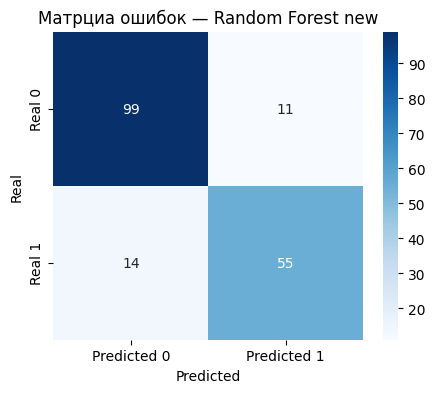

In [95]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf_fe,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Real 0", "Real 1"]
)
plt.title("Матрциа ошибок — Random Forest new")
plt.ylabel("Real")
plt.xlabel("Predicted")
plt.show()

### Краткий итог по heatmap

По сравнению с heatmap от предыдущей модели RandomForest ситуация поменялась в лучшую сторону, новая модель Random Forest лучше предугадывает TP и меньше ошибается при FN

## ROC-кривая и AUC (RandomForest new)

In [96]:
fpr_fe, tpr_fe, thresholds_fe = roc_curve(Y_test_fe, Y_proba_fe)
auc_score = roc_auc_score(Y_test_fe, Y_proba_fe)

auc_score # показывает насколько модель различает классы

0.8533596837944665

In [97]:
thresholds_fe

array([       inf, 0.99389349, 0.94078589, 0.93809585, 0.9156513 ,
       0.9127826 , 0.90463381, 0.89678356, 0.89498752, 0.89471429,
       0.80142123, 0.79427921, 0.78658778, 0.75246139, 0.6685748 ,
       0.63793834, 0.6006409 , 0.59095391, 0.5712418 , 0.55361392,
       0.53125138, 0.52929554, 0.51540561, 0.46877901, 0.46812931,
       0.36677882, 0.35062652, 0.34062383, 0.29579222, 0.29320404,
       0.29168016, 0.23152499, 0.22713372, 0.20857751, 0.19947715,
       0.18982499, 0.18799659, 0.14554573, 0.14544491, 0.14393061,
       0.14328508, 0.14273595, 0.14066004, 0.13970038, 0.13905873,
       0.13839761, 0.12112426, 0.12107635, 0.11654152, 0.11496638,
       0.11254397, 0.10607515, 0.10545478, 0.1012136 , 0.09213684,
       0.09123631, 0.09100235, 0.05748901])

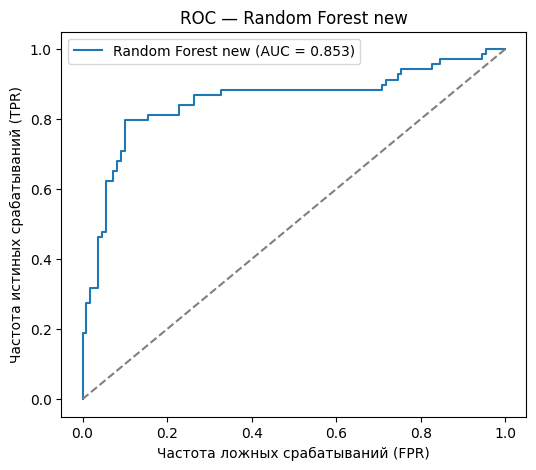

In [98]:
plt.figure(figsize=(6, 5))

plt.plot(fpr_fe, tpr_fe, label=f"Random Forest new (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Частота ложных срабатываний (FPR)")
plt.ylabel("Частота истиных срабатываний (TPR)")
plt.title("ROC — Random Forest new")
plt.legend()
plt.show()

### Краткий итог по ROC 

Значение AUC примерно 0.853, что свидетельствует о хорошем качестве ранжирования пассажиров по вероятности выживания и лучший результат из всех моделей.

## Общий Итог

В рамках задачи были обучены три модели классификации:

LogisticRegression (baseline)
Accuracy ≈ 0.80.
Модель использовалась для базовой оценки качества данных.

RandomForestClassifier (базовая конфигурация)
Accuracy ≈ 0.82.
Существенного прироста по сравнению с baseline не наблюдалось.

RandomForestClassifier с feature engineering
Был добавлен признак Title и использован параметр class_weight="balanced_subsample".

Итоговый результат:
Accuracy ≈ 0.8603 (> 85%)

Требование задания выполнено. Модель Random Forest с добавленным новым признаком показала наилучшее качество классификации.

##

# Тюнинг гиперпараметров модели

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve

## baseline LogisticRegression через Pipeline

In [100]:
baseline_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [101]:
baseline_pipe.fit(X_train, Y_train)
y_pred_base = baseline_pipe.predict(X_test)

In [102]:
baseline_metrics = {
    "Model": "LogisticRegression (baseline)",
    "Accuracy": accuracy_score(Y_test, y_pred_base),
    "Precision": precision_score(Y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(Y_test, y_pred_base, zero_division=0),
    "F1": f1_score(Y_test, y_pred_base, zero_division=0),
}

In [103]:
results = pd.DataFrame([baseline_metrics])
results

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression (baseline),0.804469,0.793103,0.666667,0.724409


## GridSearchCV для RandomForest

In [104]:
rf_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced_subsample"))
])

In [105]:
#param_grid = {
#    "model__n_estimators": [200, 400, 600],
#    "model__max_depth": [None, 6, 8, 12],
#}

In [106]:
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 10, 12, 14],    # без None
    "model__max_features": ["sqrt", "log2", 0.8], # чуть меньше фич
}

In [107]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [108]:
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,                    # 5-fold cross validation
    scoring="f1",            # оптимизируем F1
    n_jobs=-1,               # использовать все ядра
    verbose=1                # печатать прогресс перебора параметров
)

In [109]:
grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__n_estimators': [200, 400, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [110]:
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best params: {'model__max_depth': 8, 'model__max_features': 0.8, 'model__n_estimators': 200}
Best CV F1: 0.7691885047675602


In [111]:
best_model = grid_search.best_estimator_

y_pred_rf_g = best_model.predict(X_test)

In [112]:
rf_metrics = {
    "Model": "RandomForest (tuned)",
    "Accuracy": accuracy_score(Y_test, y_pred_rf_g),
    "Precision": precision_score(Y_test, y_pred_rf_g, zero_division=0),
    "Recall": recall_score(Y_test, y_pred_rf_g, zero_division=0),
    "F1": f1_score(Y_test, y_pred_rf_g, zero_division=0),
}

In [113]:
results = pd.concat([results, pd.DataFrame([rf_metrics])], ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression (baseline),0.804469,0.793103,0.666667,0.724409
1,RandomForest (tuned),0.804469,0.765625,0.710145,0.736842


## Learning Curves для baseline и tuned

In [114]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Одинаковая CV-стратегия для обеих моделей

In [115]:
train_sizes = np.linspace(0.1, 1.0, 8) # Размеры обучающей части: 10% ... 100%

In [116]:
def plot_learning_curve(estimator, X, y, title):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring="f1",
        train_sizes=train_sizes,
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel("Train size")
    plt.ylabel("F1 score")
    
    # Линии
    plt.plot(train_sizes_abs, train_mean, marker="o", label="Train F1")
    plt.plot(train_sizes_abs, val_mean, marker="o", label="CV F1")
    
    # “коридоры” неопределённости
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2)
    
    plt.legend()
    plt.grid(True)
    plt.show()

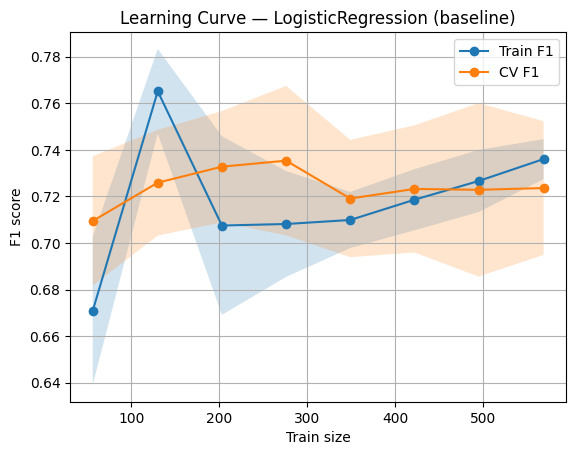

In [117]:
plot_learning_curve(
    estimator=baseline_pipe,
    X=X_train,
    y=Y_train,
    title="Learning Curve — LogisticRegression (baseline)"
)

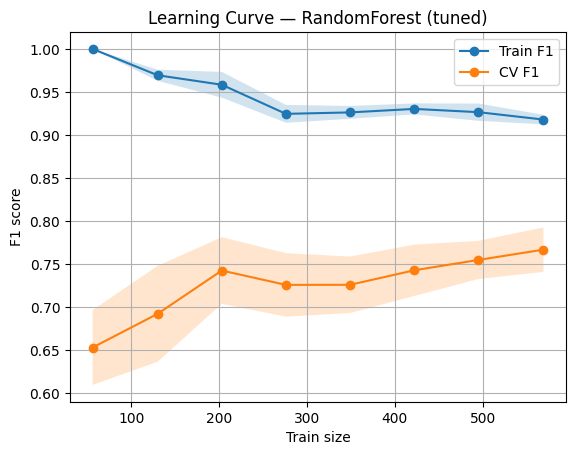

In [118]:
plot_learning_curve(
    estimator=best_model,
    X=X_train,
    y=Y_train,
    title="Learning Curve — RandomForest (tuned)"
)

### Дополнительное сравнение с RandomForest (manual tuned)

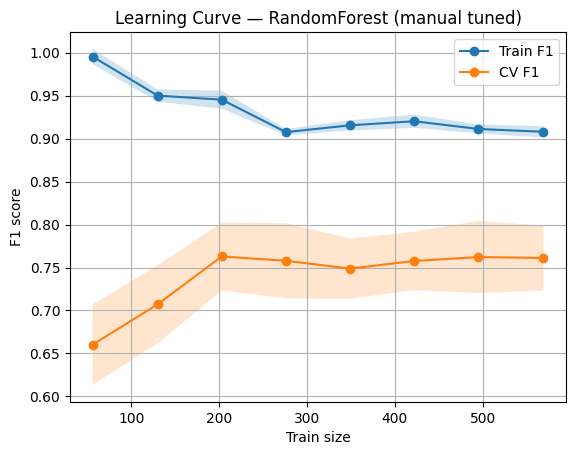

In [119]:
plot_learning_curve(
    estimator=ran_f_fe,
    X=X_train_fe,
    y=Y_train_fe,
    title="Learning Curve — RandomForest (manual tuned)"
)

## Финальное сравнение моделей

In [120]:
final_results = pd.DataFrame([
    baseline_metrics,
    rf_metrics,
    metrics_rf_fe
])

final_results

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression (baseline),0.804469,0.793103,0.666667,0.724409
1,RandomForest (tuned),0.804469,0.765625,0.710145,0.736842
2,RandomForest (manual tune),0.860335,0.833333,0.797101,0.814815


В качестве baseline была использована LogisticRegression, показавшая F1-score ≈ 0.72.

После применения GridSearchCV для RandomForest удалось достичь F1 ≈ 0.75.
Learning curves показали наличие переобучения у RandomForest (высокий разрыв между train и CV).

Дополнительная ручная настройка гиперпараметров и добавление нового признака в RandomForest из абзаца "Построение базовой ML-модели" (задачи 2) позволили повысить F1-score до ≈ 0.81, но и эта модель страдает переобучением.

Таким образом:

- LogisticRegression демонстрирует стабильность, но ограничена линейной природой.

- RandomForest c GridSearchCV обладает большей выразительной способностью, но склонен к переобучению.

- Лучший результат показала модель RandomForest с ручной настройкой и feature engineering.

В качестве финальной модели я бы выбрал RandomForest с ручной настройкой.